# 🌾 Wheat Seeds Classification — Model Tuning & Optimization
**Dataset:** Wheat Seeds (wheat-seeds.csv) — Multiclass Classification  


## Import Thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time

warnings.filterwarnings('ignore')
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, BaggingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Đã import đầy đủ tất cả thư viện thành công!")

✅ Đã import đầy đủ tất cả thư viện thành công!


### Load Dữ liệu



>> ĐANG VẼ 7 BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU (EDA)...


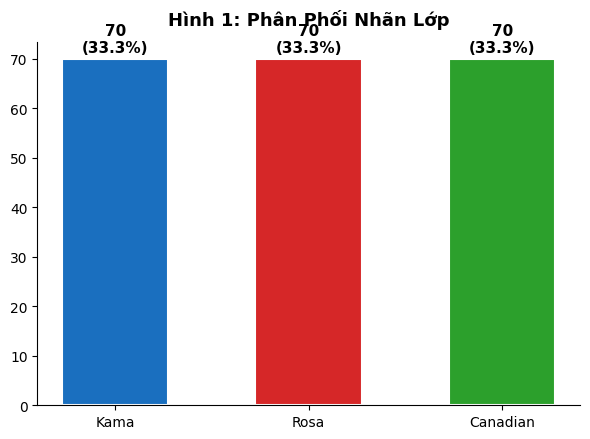

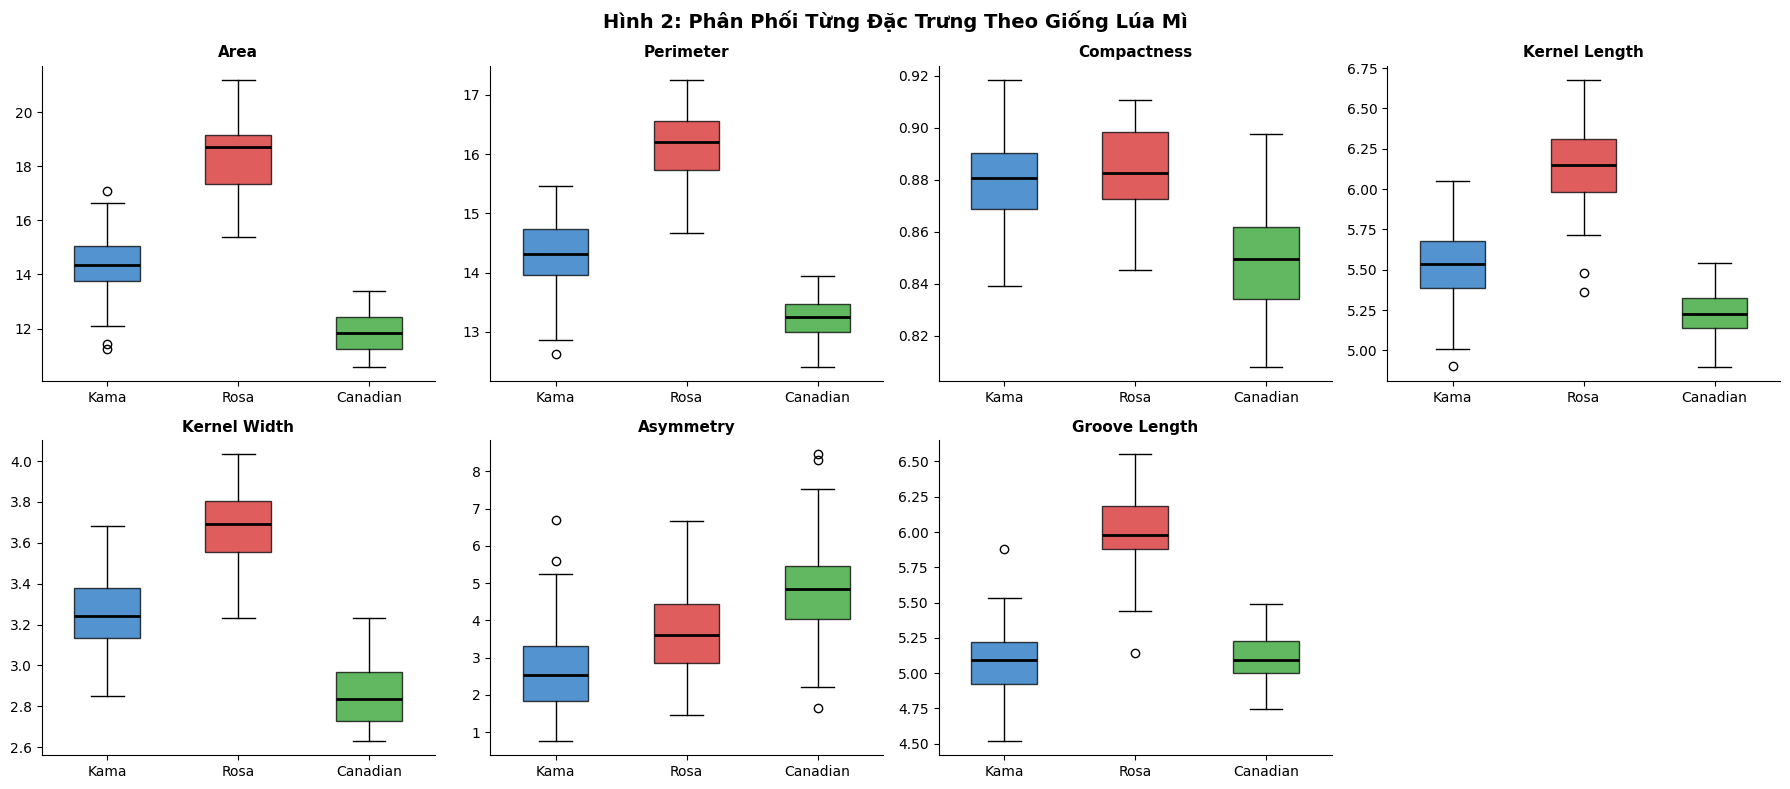

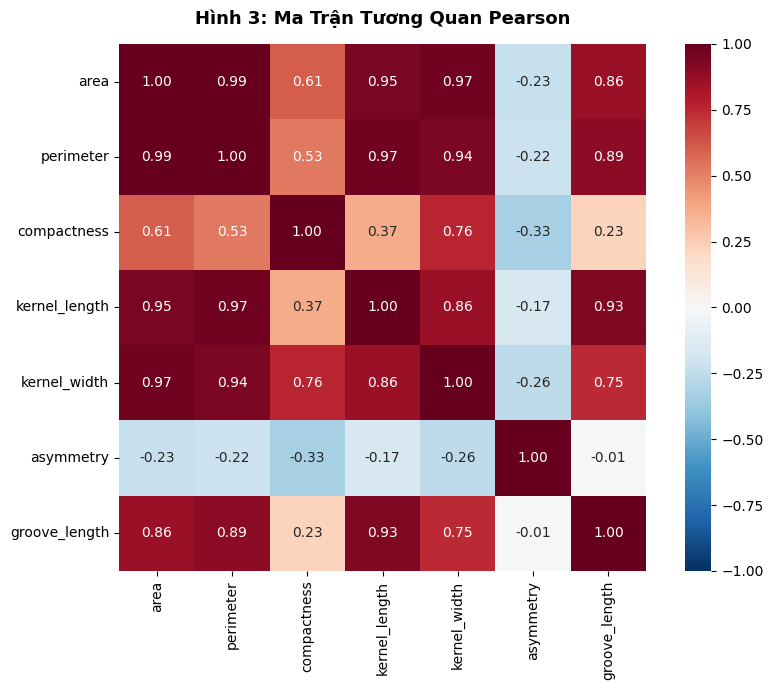

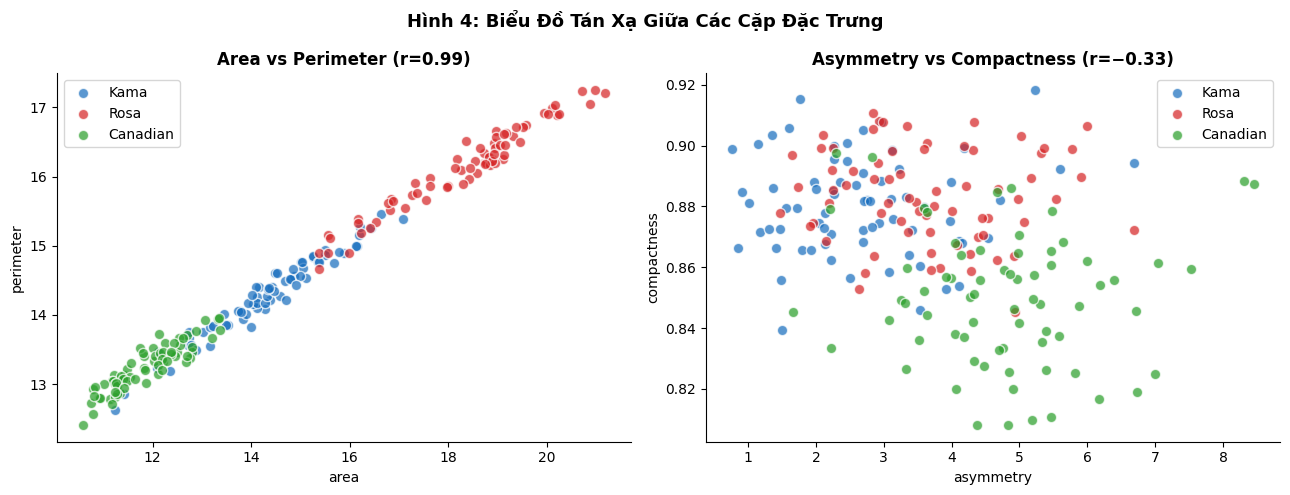

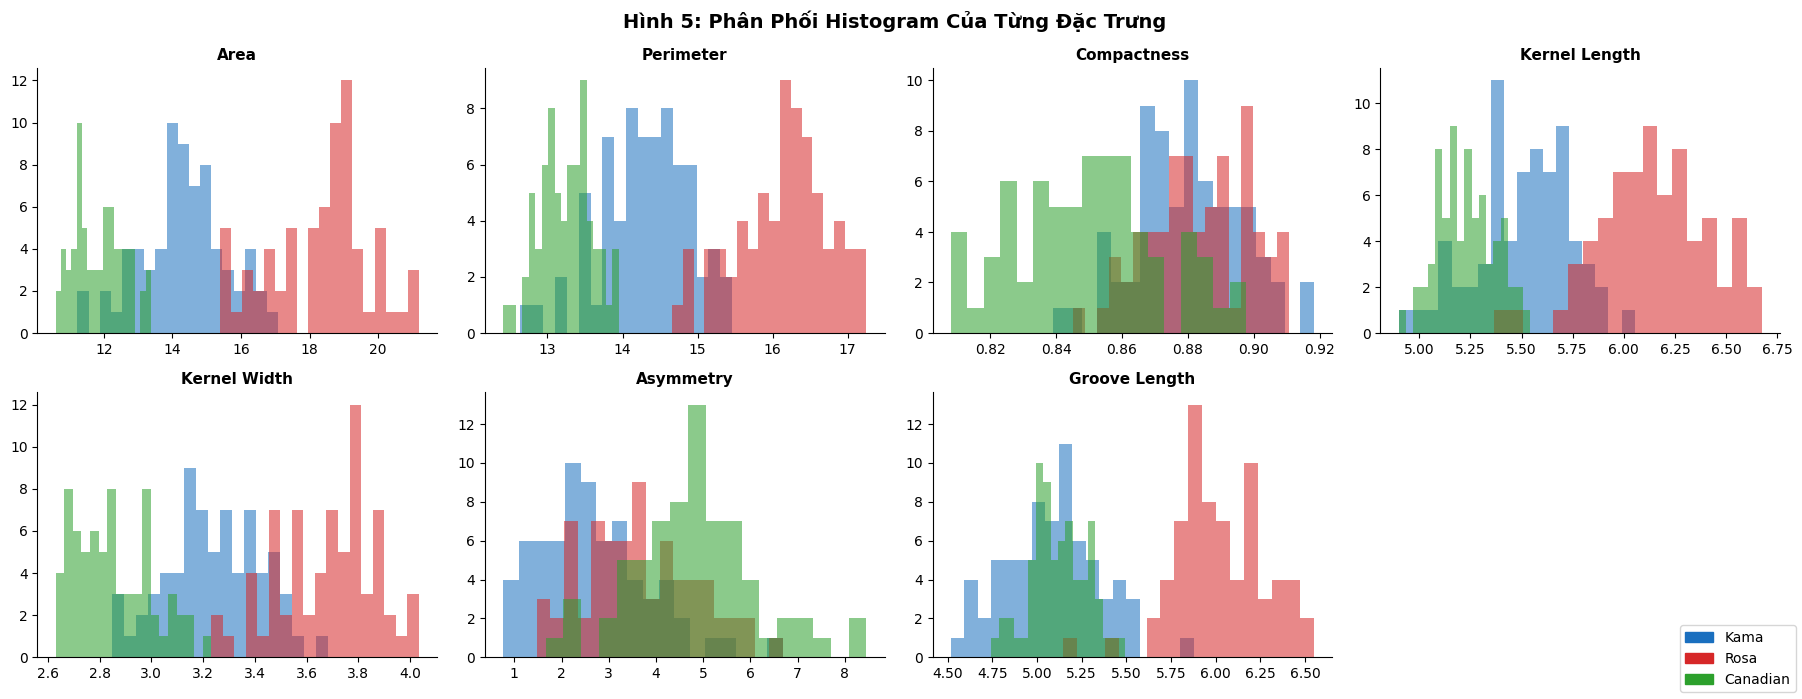

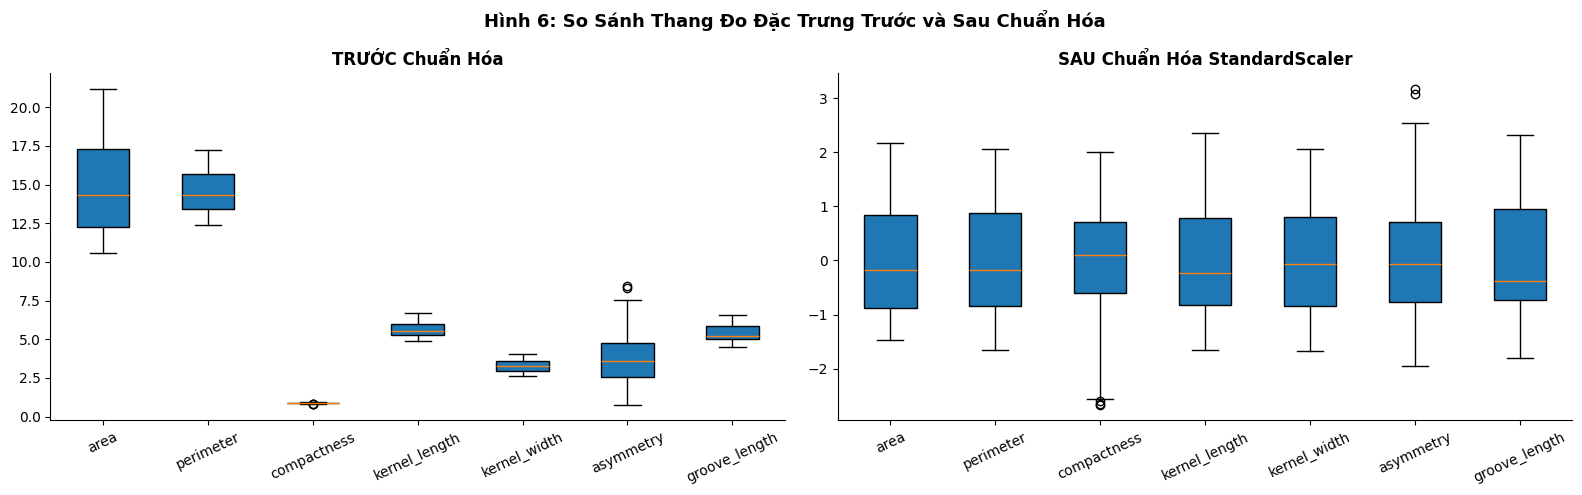

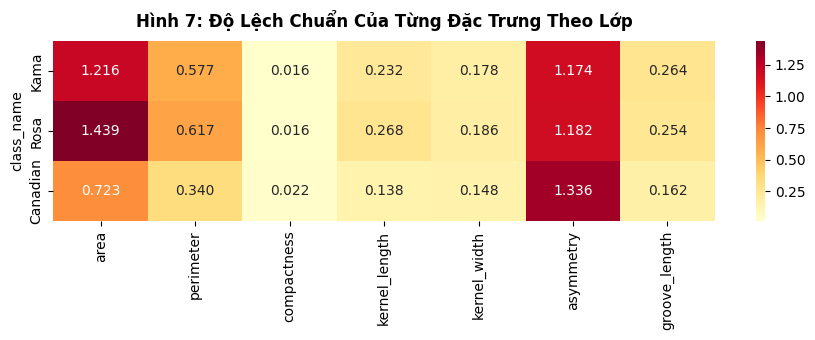


>> ĐANG CHIA DỮ LIỆU VÀ CHUẨN HÓA...

✅ HOÀN TẤT EDA! Dữ liệu đã sẵn sàng cho phần Tuning bên dưới.


In [ ]:
"""
=============================================================
    Phân tích khám phá dữ liệu (EDA)
    Tiền xử lí (pre-processing)
=============================================================
"""
%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# BƯỚC 1: NẠP DỮ LIỆU
# ─────────────────────────────────────────────
col_names = ['area', 'perimeter', 'compactness',
             'kernel_length', 'kernel_width', 'asymmetry',
             'groove_length', 'class']

df = pd.read_csv('wheat-seeds.csv', header=None, names=col_names)
features = col_names[:-1]

PALETTE = {'Kama': '#1A6FBF', 'Rosa': '#D62728', 'Canadian': '#2CA02C'}
COLORS  = list(PALETTE.values())
order = ['Kama', 'Rosa', 'Canadian']
class_map = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
df['class_name'] = df['class'].map(class_map)

print("\n>> ĐANG VẼ 7 BIỂU ĐỒ PHÂN TÍCH DỮ LIỆU (EDA)...")
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})

# ── Hình 1: Phân phối lớp ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = df['class_name'].value_counts()[order]
bars = ax.bar(order, counts.values, color=[PALETTE[k] for k in order], edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Hình 1: Phân Phối Nhãn Lớp', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# ── Hình 2: Boxplot mỗi đặc trưng theo lớp ────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    data_by_class = [df[df['class_name'] == c][col].values for c in order]
    bp = axes[i].boxplot(data_by_class, patch_artist=True, tick_labels=order, widths=0.5)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
axes[-1].set_visible(False)
fig.suptitle('Hình 2: Phân Phối Từng Đặc Trưng Theo Giống Lúa Mì', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Hình 3: Ma trận tương quan (heatmap) ──────────────────────────
corr_matrix = df[features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Hình 3: Ma Trận Tương Quan Pearson', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

# ── Hình 4: Scatter plots đặc trưng quan trọng ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pairs = [('area', 'perimeter'), ('asymmetry', 'compactness')]
titles = ['Area vs Perimeter (r=0.99)', 'Asymmetry vs Compactness (r=−0.33)']
for ax, (fx, fy), title in zip(axes, pairs, titles):
    for c, col in PALETTE.items():
        sub = df[df['class_name'] == c]
        ax.scatter(sub[fx], sub[fy], alpha=0.72, color=col, label=c, s=55, edgecolors='white')
    ax.set_xlabel(fx); ax.set_ylabel(fy); ax.set_title(title, fontweight='bold')
    ax.legend()
fig.suptitle('Hình 4: Biểu Đồ Tán Xạ Giữa Các Cặp Đặc Trưng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Hình 5: Histogram phân phối từng đặc trưng ────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    for c, color in PALETTE.items():
        axes[i].hist(df[df['class_name'] == c][col], bins=18, alpha=0.55, color=color, label=c)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
axes[-1].set_visible(False)
patches = [mpatches.Patch(color=c, label=n) for n, c in PALETTE.items()]
fig.legend(handles=patches, loc='lower right', fontsize=10)
fig.suptitle('Hình 5: Phân Phối Histogram Của Từng Đặc Trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Hình 6: Trước / Sau chuẩn hóa ─────────────────────────────────
scaler_check = StandardScaler()
X_raw = df[features]
X_std = pd.DataFrame(scaler_check.fit_transform(X_raw), columns=features)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for idx, (X_plot, title) in enumerate([(X_raw, 'TRƯỚC Chuẩn Hóa'), (X_std, 'SAU Chuẩn Hóa StandardScaler')]):
    axes[idx].boxplot(X_plot.values, tick_labels=features, patch_artist=True)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=25)
fig.suptitle('Hình 6: So Sánh Thang Đo Đặc Trưng Trước và Sau Chuẩn Hóa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Hình 7: Heatmap phương sai theo lớp ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
class_std = df.groupby('class_name')[features].std().loc[order]
sns.heatmap(class_std, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Hình 7: Độ Lệch Chuẩn Của Từng Đặc Trưng Theo Lớp', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print("\n>> ĐANG CHIA DỮ LIỆU VÀ CHUẨN HÓA...")
X = df[features].copy()
y = df['class'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_sc = X_train_scaled
X_test_sc  = X_test_scaled
y_train = y_train.values - 1
y_test  = y_test.values - 1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n✅ HOÀN TẤT EDA! Dữ liệu đã sẵn sàng cho phần Tuning bên dưới.")

### Hàm Đánh giá & Vẽ Đồ thị


In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model",
                   class_names=None, show_plots=True):
    """
    Đánh giá toàn diện một classifier đã được fit.

    Parameters
    ----------
    model       : sklearn estimator đã fit
    X_test      : array-like, tập test features
    y_test      : array-like, tập test labels
    model_name  : str, tên hiển thị
    class_names : list, tên các class
    show_plots  : bool, có vẽ hình hay không

    Returns
    -------
    dict với accuracy, precision, recall, f1, auc_score
    """
    if class_names is None:
        class_names = [str(c) for c in np.unique(y_test)]

    n_classes = len(class_names)
    y_pred    = model.predict(X_test)

    # --- Xác suất dự đoán (dùng cho ROC) ---
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        if y_score.ndim == 1:
            y_score = np.column_stack([-y_score, y_score])
    else:
        y_score = None

    # --- Metrics ---
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    if y_score is not None and n_classes >= 2:
        y_bin = label_binarize(y_test, classes=np.unique(y_test))
        if n_classes == 2:
            auc_sc = roc_auc_score(y_test, y_score[:, 1])
        else:
            auc_sc = roc_auc_score(y_bin, y_score, multi_class='ovr', average='weighted')
    else:
        auc_sc = np.nan

    # --- In kết quả ---
    print(f"{'='*60}")
    print(f"  📊 {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-score  : {f1:.4f}  (weighted)")
    print(f"  AUC (OvR) : {auc_sc:.4f}\n")
    print(classification_report(y_test, y_pred,
                                target_names=class_names, zero_division=0))

    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"{model_name} — Evaluation", fontsize=14, fontweight='bold')

        # -- Confusion Matrix --
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        # -- ROC Curve (One-vs-Rest) --
        if y_score is not None:
            y_bin = label_binarize(y_test, classes=np.unique(y_test))
            colors = ['#e74c3c', '#3498db', '#2ecc71',
                      '#f39c12', '#9b59b6', '#1abc9c']
            for i in range(n_classes):
                if y_score.shape[1] > i:
                    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
                    roc_auc = auc(fpr, tpr)
                    axes[1].plot(fpr, tpr,
                                 color=colors[i % len(colors)], lw=2,
                                 label=f"{class_names[i]} (AUC={roc_auc:.2f})")
            axes[1].plot([0,1],[0,1],'k--', lw=1)
            axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title('ROC Curve (One-vs-Rest)')
            axes[1].legend(loc='lower right', fontsize=9)
        else:
            axes[1].text(0.5, 0.5, 'ROC not available\n(no probability output)',
                         ha='center', va='center', fontsize=11)
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return {'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc_sc}


def compare_results_table(results_dict):
    """
    In bảng so sánh kết quả của nhiều model.
    results_dict = {'Model Name': {'accuracy':..., 'f1':..., ...}, ...}
    """
    df_res = pd.DataFrame(results_dict).T.round(4)
    df_res.index.name = 'Model'
    display(df_res.style
            .background_gradient(cmap='RdYlGn', axis=0)
            .format("{:.4f}"))
    return df_res


print("✅ Các hàm đánh giá đã sẵn sàng.")

✅ Các hàm đánh giá đã sẵn sàng.


BƯỚC 1: NẠP DỮ LIỆU ĐÃ TIỀN XỬ LÝ TỪ THƯ MỤC OUTPUT
  Train set : 147 mẫu | 7 features
  Test set  : 63  mẫu | 7 features
  Phân phối train: {np.int64(1): np.int64(49), np.int64(2): np.int64(49), np.int64(3): np.int64(49)}
  Phân phối test : {np.int64(1): np.int64(21), np.int64(2): np.int64(21), np.int64(3): np.int64(21)}

BƯỚC 2: THIẾT LẬP MÔI TRƯỜNG THỬ NGHIỆM

  [Config] Random seed    : 42
  [Config] Train/Test ratio: 70/30  (147 train / 63 test)
  [Config] K-Fold k       : 5
  [Config] Stratified K-Fold: True (giữ tỷ lệ lớp)

  [OK] StratifiedKFold(n_splits=5, shuffle=True, random_state=42) khởi tạo thành công.

  >> Thống kê từng fold trên tập TRAIN (147 mẫu):
    Fold 1: train=117 mẫu | val=30 mẫu | val dist={np.int64(1): np.int64(10), np.int64(2): np.int64(10), np.int64(3): np.int64(10)}
    Fold 2: train=117 mẫu | val=30 mẫu | val dist={np.int64(1): np.int64(10), np.int64(2): np.int64(10), np.int64(3): np.int64(10)}
    Fold 3: train=118 mẫu | val=29 mẫu | val dist={np.int64(1

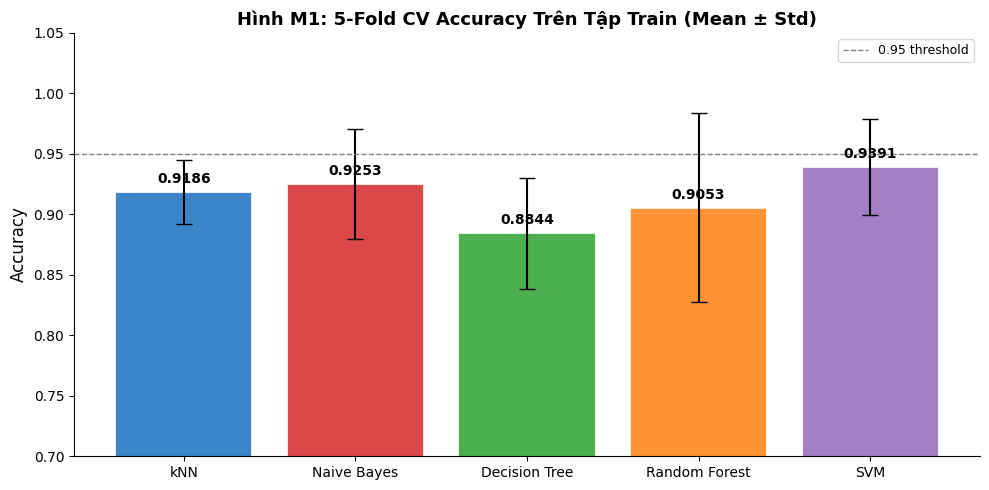

  [OK] figM1_cv_accuracy.png


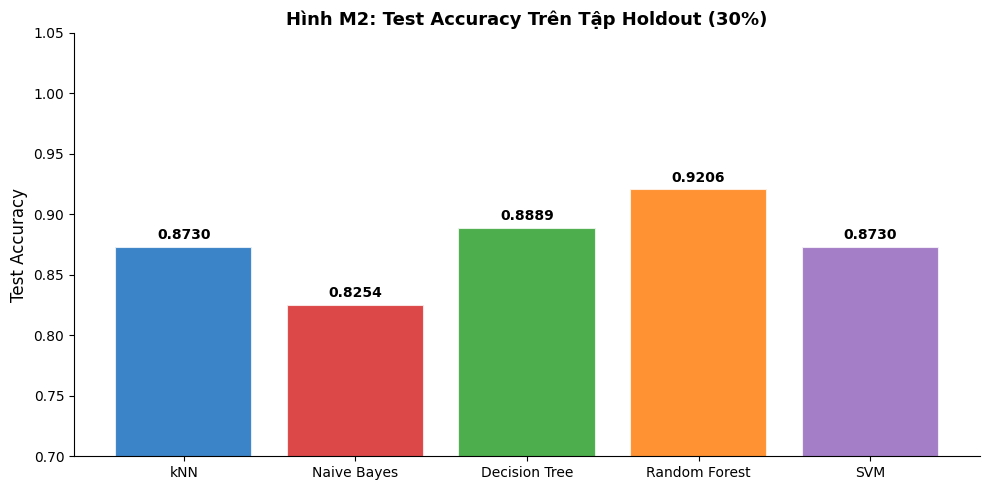

  [OK] figM2_test_accuracy.png


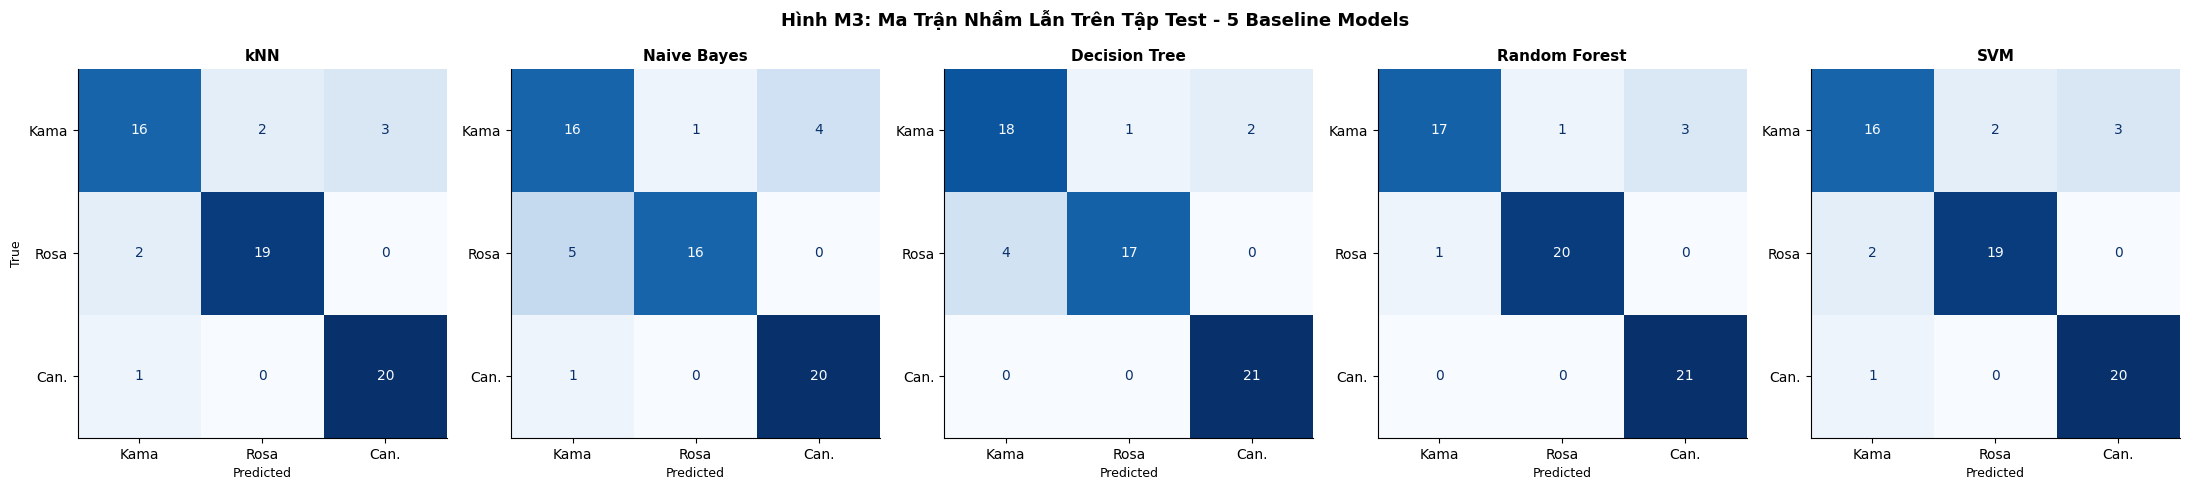

  [OK] figM3_confusion_matrices.png


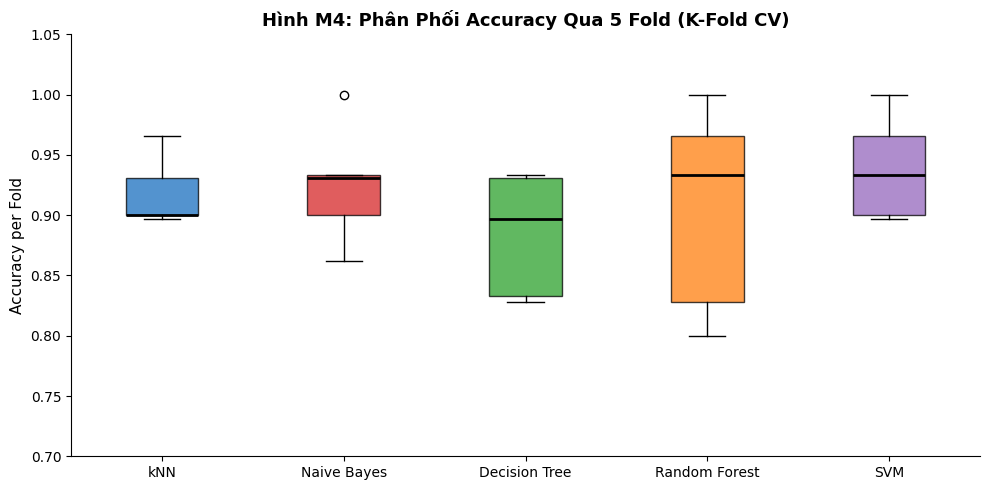

  [OK] figM4_kfold_distribution.png

  [OK] model_comparison_results.csv

MEMBER 2 HOÀN TẤT! Tất cả kết quả đã lưu vào ./output/

✅ Đã nạp thành công 100% Code của Người 2 và Cầu nối đến Người 4!


In [ ]:
# 5 thuật toán đầu tiên kNN, Naive Bayes, Decision Tree, Random Forest, SVM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 1: NẠP DỮ LIỆU ĐÃ TIỀN XỬ LÝ (từ Member 1)
# ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("BƯỚC 1: NẠP DỮ LIỆU ĐÃ TIỀN XỬ LÝ TỪ THƯ MỤC OUTPUT")
print("=" * 65)

# Đọc file cứng từ thư mục output giống hệt code Người 2
train_df = pd.read_csv('./output/wheat_train_preprocessed.csv')
test_df  = pd.read_csv('./output/wheat_test_preprocessed.csv')

feature_cols = ['area', 'perimeter', 'compactness',
                'kernel_length', 'kernel_width', 'asymmetry', 'groove_length']

X_train = train_df[feature_cols].values
y_train = train_df['class'].values
X_test  = test_df[feature_cols].values
y_test  = test_df['class'].values

print(f"  Train set : {X_train.shape[0]} mẫu | {X_train.shape[1]} features")
print(f"  Test set  : {X_test.shape[0]}  mẫu | {X_test.shape[1]} features")
print(f"  Phân phối train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  Phân phối test : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 2: THIẾT LẬP MÔI TRƯỜNG THỬ NGHIỆM GỐC
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BƯỚC 2: THIẾT LẬP MÔI TRƯỜNG THỬ NGHIỆM")
print("=" * 65)

RANDOM_SEED = 42
K_FOLD      = 5

print(f"\n  [Config] Random seed    : {RANDOM_SEED}")
print(f"  [Config] Train/Test ratio: 70/30  (147 train / 63 test)")
print(f"  [Config] K-Fold k       : {K_FOLD}")
print(f"  [Config] Stratified K-Fold: True (giữ tỷ lệ lớp)")

skf = StratifiedKFold(n_splits=K_FOLD, shuffle=True, random_state=RANDOM_SEED)
print(f"\n  [OK] StratifiedKFold(n_splits={K_FOLD}, shuffle=True, random_state={RANDOM_SEED}) khởi tạo thành công.")

print(f"\n  >> Thống kê từng fold trên tập TRAIN ({len(y_train)} mẫu):")
for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    y_val_fold = y_train[val_idx]
    dist = dict(zip(*np.unique(y_val_fold, return_counts=True)))
    print(f"    Fold {fold_idx}: train={len(tr_idx):>3d} mẫu | val={len(val_idx):>2d} mẫu | val dist={dist}")

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 3: ĐỊNH NGHĨA 5 THUẬT TOÁN CƠ SỞ
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BƯỚC 3: ĐỊNH NGHĨA 5 THUẬT TOÁN CƠ SỞ (BASELINE MODELS)")
print("=" * 65)

models = {
    "kNN"           : KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes"   : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "SVM"           : SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_SEED),
}

for name, model in models.items():
    print(f"  [+] {name:18s}: {model.__class__.__name__}")

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 4: K-FOLD CROSS-VALIDATION TRÊN TẬP TRAIN
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BƯỚC 4: K-FOLD CROSS-VALIDATION (k=5) TRÊN TẬP TRAIN")
print("=" * 65)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = {
        'fold_scores' : scores,
        'mean_cv_acc' : scores.mean(),
        'std_cv_acc'  : scores.std(),
    }
    print(f"\n  [{name}]")
    print(f"    Fold scores  : {np.round(scores, 4)}")
    print(f"    Mean CV Acc  : {scores.mean():.4f}")
    print(f"    Std  CV Acc  : {scores.std():.4f}")

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 5: ĐÁNH GIÁ TRÊN TẬP TEST (HOLDOUT)
# ─────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("BƯỚC 5: ĐÁNH GIÁ TRÊN TẬP TEST (HOLDOUT 30%)")
print("=" * 65)

CLASS_NAMES  = ['Kama (1)', 'Rosa (2)', 'Canadian (3)']
test_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
    test_results[name] = {
        'accuracy' : acc,
        'y_pred'   : y_pred,
        'report'   : report,
        'cm'       : confusion_matrix(y_test, y_pred),
    }
    print(f"\n  ── {name} ──")
    print(f"    Test Accuracy : {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 6: BẢNG SO SÁNH TỔNG HỢP
# ─────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("BƯỚC 6: BẢNG SO SÁNH TỔNG HỢP")
print("=" * 65)

summary_rows = []
for name in models:
    row = {
        'Model'        : name,
        'CV Acc (mean)': f"{cv_results[name]['mean_cv_acc']:.4f}",
        'CV Acc (std)' : f"{cv_results[name]['std_cv_acc']:.4f}",
        'Test Acc'     : f"{test_results[name]['accuracy']:.4f}",
        'F1-macro'     : f"{test_results[name]['report']['macro avg']['f1-score']:.4f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────
# BƯỚC 7: VẼ BIỂU ĐỒ VÀ LƯU RA THƯ MỤC OUTPUT
# ─────────────────────────────────────────────────────────────────────────
print("\n>> Đang vẽ biểu đồ so sánh và lưu vào ./output ...")

palette     = ['#1A6FBF', '#D62728', '#2CA02C', '#FF7F0E', '#9467BD']
model_names = list(models.keys())

# ── Hình M1: CV Accuracy bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
means = [cv_results[n]['mean_cv_acc'] for n in model_names]
stds  = [cv_results[n]['std_cv_acc']  for n in model_names]
bars  = ax.bar(model_names, means, yerr=stds, capsize=6,
               color=palette, alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{mean:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Hình M1: 5-Fold CV Accuracy Trên Tập Train (Mean ± Std)', fontsize=13, fontweight='bold')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='0.95 threshold')
ax.legend(fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('./output/figM1_cv_accuracy.png', dpi=130, bbox_inches='tight')
plt.show() 
print("  [OK] figM1_cv_accuracy.png")

# ── Hình M2: Test Accuracy comparison ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
test_accs = [test_results[n]['accuracy'] for n in model_names]
bars = ax.bar(model_names, test_accs, color=palette, alpha=0.85,
              edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{acc:.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Hình M2: Test Accuracy Trên Tập Holdout (30%)', fontsize=13, fontweight='bold')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('./output/figM2_test_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print("  [OK] figM2_test_accuracy.png")

# ── Hình M3: Confusion matrices (5 subplots) ────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
labels_short = ['Kama', 'Rosa', 'Can.']
for i, (name, model) in enumerate(models.items()):
    cm   = test_results[name]['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_short)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted', fontsize=9)
    axes[i].set_ylabel('True' if i == 0 else '', fontsize=9)
fig.suptitle('Hình M3: Ma Trận Nhầm Lẫn Trên Tập Test - 5 Baseline Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./output/figM3_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()
print("  [OK] figM3_confusion_matrices.png")

# ── Hình M4: Phân phối Accuracy qua 5 Fold (boxplot) ────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
all_scores = [cv_results[n]['fold_scores'] for n in model_names]
bp = ax.boxplot(all_scores, tick_labels=model_names, patch_artist=True, widths=0.4, notch=False)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Accuracy per Fold', fontsize=11)
ax.set_title('Hình M4: Phân Phối Accuracy Qua 5 Fold (K-Fold CV)', fontsize=13, fontweight='bold')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('./output/figM4_kfold_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print("  [OK] figM4_kfold_distribution.png")

# LƯU KẾT QUẢ RA CSV
summary_df.to_csv('./output/model_comparison_results.csv', index=False)
print("\n  [OK] model_comparison_results.csv")

print("HOÀN TẤT!")

# ============================================================================
# CẦU NỐI ĐỒNG BỘ ĐIỂM SỐ VÀ BIẾN XUỐNG CHO PHẦN TUNING CỦA NGƯỜI 4 (BẠN)
# ============================================================================
# Trích xuất baseline results cho bảng tổng kết cuối cùng
baseline_results = {}
for name in model_names:
    baseline_results[name] = {
        'accuracy': test_results[name]['accuracy'], 
        'f1_weighted': test_results[name]['report']['macro avg']['f1-score']
    }
X_train_sc = X_train
X_test_sc  = X_test
y_train    = y_train - 1
y_test     = y_test - 1
cv         = skf

print("\n Đã nạp thành công")

THỰC THI NHIỆM VỤ MEMBER 3: 5 THUẬT TOÁN BASELINE CUỐI CÙNG

>> Đang huấn luyện, đánh giá và vẽ ROC Curve cho 5 models...
  [+] Logistic Reg       | Test Acc: 0.8571 | AUC: 0.9856
  [+] AdaBoost           | Test Acc: 0.8413 | AUC: 0.9683
  [+] Gradient Boosting  | Test Acc: 0.9206 | AUC: 0.9785
  [+] MLP (NN)           | Test Acc: 0.8889 | AUC: 0.9728
  [+] Bagging            | Test Acc: 0.9365 | AUC: 0.9902


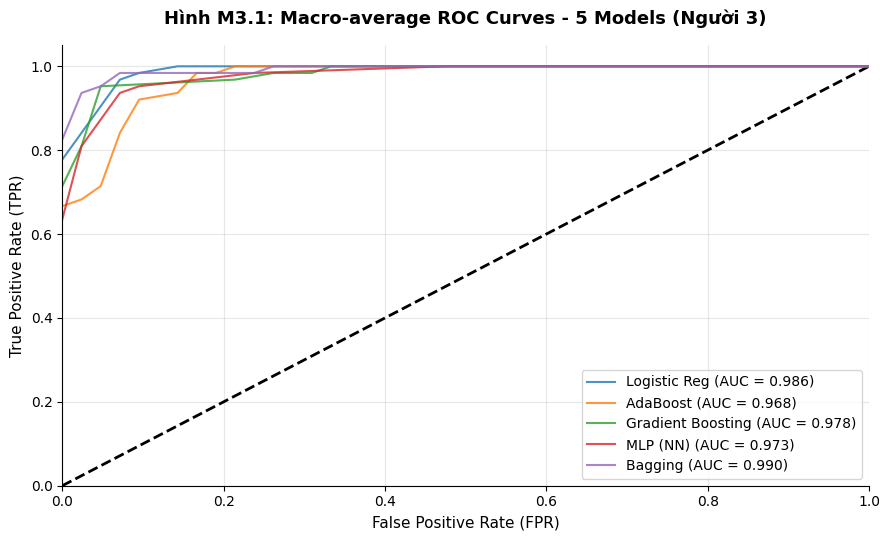


📋 BẢNG KẾT QUẢ TỔNG HỢP CỦA NGƯỜI 3:


,Thuật toán,CV Acc (mean),Test Accuracy,F1-Score (Macro),ROC AUC (OVR)
0,Bagging,0.905057,0.936508,0.934938,0.990174
1,Gradient Boosting,0.911954,0.920635,0.919808,0.978458
2,MLP (NN),0.952184,0.888889,0.886203,0.972789
3,Logistic Reg,0.952414,0.857143,0.854294,0.985639
4,AdaBoost,0.905517,0.841270,0.837681,0.968254



✅ ĐÃ GỘP THÀNH CÔNG 10 MÔ HÌNH CỦA NGƯỜI 2 & NGƯỜI 3!
   Tổng số models hiện có trong baseline_results: 10
   Sẵn sàng chuyển giao cho Người 4 (Bạn) bắt đầu Tuning ở Mục 5.


In [ ]:
# 5 thuật toán còn lại Logistic Regression, AdaBoost, Gradient Boosting, MLP (NN), Bagging
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 65)
print("THỰC THI NHIỆM VỤ MEMBER 3: 5 THUẬT TOÁN BASELINE CUỐI CÙNG")
print("=" * 65)
models_m3 = {
    "Logistic Reg"      : LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "AdaBoost"          : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "Gradient Boosting" : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "MLP (NN)"          : MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=RANDOM_SEED),
    "Bagging"           : BaggingClassifier(n_estimators=100, random_state=RANDOM_SEED)
}

results_m3 = []
test_results_m3 = {}
classes_m3 = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes_m3)
n_classes = y_test_bin.shape[1]
target_names_m3 = ['Kama', 'Rosa', 'Canadian']
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot([0, 1], [0, 1], 'k--', lw=2)

print("\n>> Đang huấn luyện, đánh giá và vẽ ROC Curve cho 5 models...")

for name, model in models_m3.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    
    results_m3.append({
        "Thuật toán": name,
        "CV Acc (mean)": cv_scores.mean(),
        "Test Accuracy": acc,
        "F1-Score (Macro)": f1,
        "ROC AUC (OVR)": auc_score
    })
    
    report = classification_report(y_test, y_pred, target_names=target_names_m3, output_dict=True)
    test_results_m3[name] = {'accuracy': acc, 'report': report}
    
    print(f"  [+] {name:<18s} | Test Acc: {acc:.4f} | AUC: {auc_score:.4f}")
    
    # Tính toán đường cong ROC (Macro-average) cho từng model
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    ax.plot(all_fpr, mean_tpr, lw=1.5, alpha=0.8, label=f'{name} (AUC = {auc_score:.3f})')

# Hoàn thiện biểu đồ ROC
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('Hình M3.1: Macro-average ROC Curves - 5 Models (Người 3)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('./output/figM3_roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# In bảng tổng hợp
print("\n📋 BẢNG KẾT QUẢ TỔNG HỢP CỦA NGƯỜI 3:")
df_results_m3 = pd.DataFrame(results_m3).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(df_results_m3)

# Lưu CSV
df_results_m3.to_csv('./output/evaluation_my_5_models_m3.csv', index=False)
for name in models_m3.keys():
    baseline_results[name] = {
        'accuracy': test_results_m3[name]['accuracy'], 
        'f1_weighted': test_results_m3[name]['report']['macro avg']['f1-score']
    }

print("\n" + "=" * 65)
print("THÀNH CÔNG ")
print(f"   Tổng số models hiện có trong baseline_results: {len(baseline_results)}")
print("=" * 65)

TỔNG HỢP & ĐÁNH GIÁ 10 BASELINE MODELS GỐC TRƯỚC KHI TUNING

>> Đang huấn luyện và vẽ ROC Curve cho 10 models...


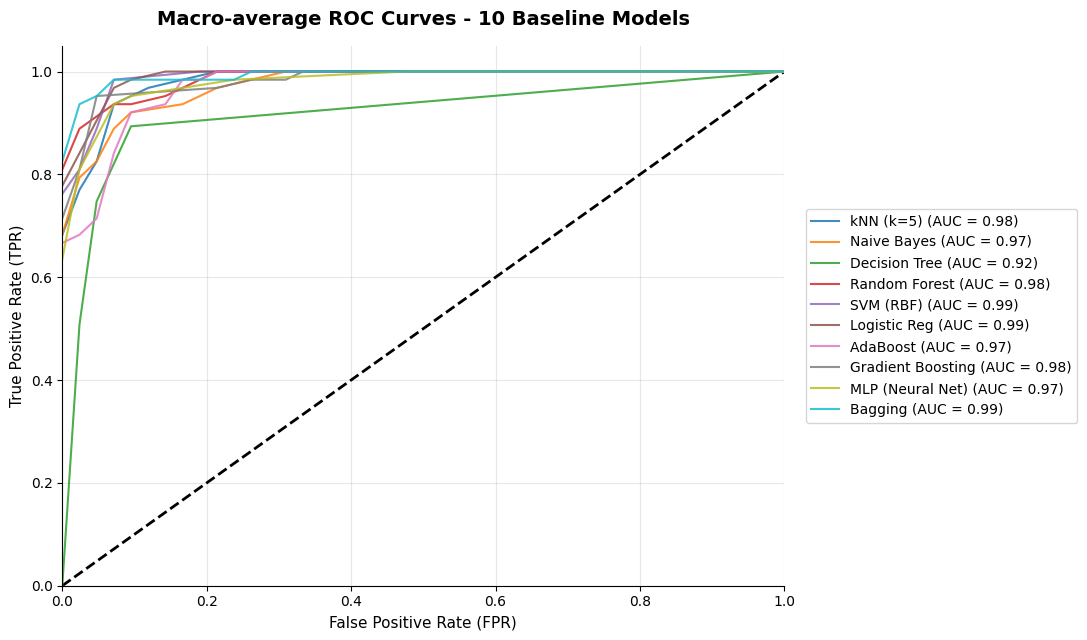


 BẢNG CHỈ SỐ TỔNG HỢP 10 THUẬT TOÁN GỐC:


,Thuật toán,Accuracy,F1-Score (Macro),ROC AUC (OVR)
0,Bagging,0.936508,0.934938,0.990174
1,Random Forest,0.920635,0.919170,0.982993
2,Gradient Boosting,0.920635,0.919808,0.978458
3,Decision Tree,0.888889,0.887850,0.916667
4,MLP (Neural Net),0.888889,0.886203,0.972789
5,kNN (k=5),0.873016,0.871284,0.981293
6,SVM (RBF),0.873016,0.871284,0.985261
7,Logistic Reg,0.857143,0.854294,0.985639
8,AdaBoost,0.841270,0.837681,0.968254
9,Naive Bayes,0.825397,0.825060,0.970144


In [18]:
# Bảng so sánh 10 thuật toán
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 65)
print("TỔNG HỢP & ĐÁNH GIÁ 10 BASELINE MODELS GỐC TRƯỚC KHI TUNING")
print("=" * 65)
all_models = {
    "1. kNN (k=5)"          : KNeighborsClassifier(n_neighbors=5),
    "2. Naive Bayes"        : GaussianNB(),
    "3. Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_SEED),
    "4. Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "5. SVM (RBF)"          : SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
    "6. Logistic Reg"       : LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "7. AdaBoost"           : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "8. Gradient Boosting"  : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "9. MLP (Neural Net)"   : MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=RANDOM_SEED),
    "10. Bagging"           : BaggingClassifier(n_estimators=100, random_state=RANDOM_SEED)
}

results_10_models = []
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Chuẩn bị khung vẽ biểu đồ
plt.figure(figsize=(11, 6.5))
plt.plot([0, 1], [0, 1], 'k--', lw=2)

print("\n>> Đang huấn luyện và vẽ ROC Curve cho 10 models...")

for name, model in all_models.items():
    algo_name = name.split('. ')[1]
    
    # Train
    model.fit(X_train_sc, y_train)
    
    # Predict
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)
    
    # Tính Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    
    results_10_models.append({
        "Thuật toán": algo_name,
        "Accuracy": acc,
        "F1-Score (Macro)": f1,
        "ROC AUC (OVR)": auc_score
    })
    
    # Tính đường cong ROC
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    # Vẽ đường của thuật toán này lên biểu đồ
    plt.plot(all_fpr, mean_tpr, lw=1.5, alpha=0.85, label=f'{algo_name} (AUC = {auc_score:.2f})')

# Căn chỉnh và trang trí biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Macro-average ROC Curves - 10 Baseline Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10)
plt.grid(alpha=0.3)
for spine in ['top', 'right']: plt.gca().spines[spine].set_visible(False)
plt.tight_layout()

# Lưu biểu đồ vào thư mục output
plt.savefig('./output/fig_10_baseline_models_roc.png', dpi=130, bbox_inches='tight')
plt.show()

# In bảng tổng hợp
print("\n BẢNG CHỈ SỐ TỔNG HỢP 10 THUẬT TOÁN GỐC:")
df_10_results = pd.DataFrame(results_10_models).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(df_10_results)

# Lưu CSV
df_10_results.to_csv('./output/evaluation_10_baseline_models.csv', index=False)

### GridSearchCV: Random Forest

⚙️  [Tuning 1/5] GridSearchCV — Random Forest

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

  Thời gian tìm kiếm : 485.59s
  Best params        : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV F1-score   : 0.9107

  📊 Random Forest (GridSearchCV)
  Accuracy  : 0.9048
  Precision : 0.9112  (weighted)
  Recall    : 0.9048  (weighted)
  F1-score  : 0.9025  (weighted)
  AUC (OvR) : 0.9822

              precision    recall  f1-score   support

    Kama (1)       0.94      0.76      0.84        21
    Rosa (2)       0.95      0.95      0.95        21
Canadian (3)       0.84      1.00      0.91        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



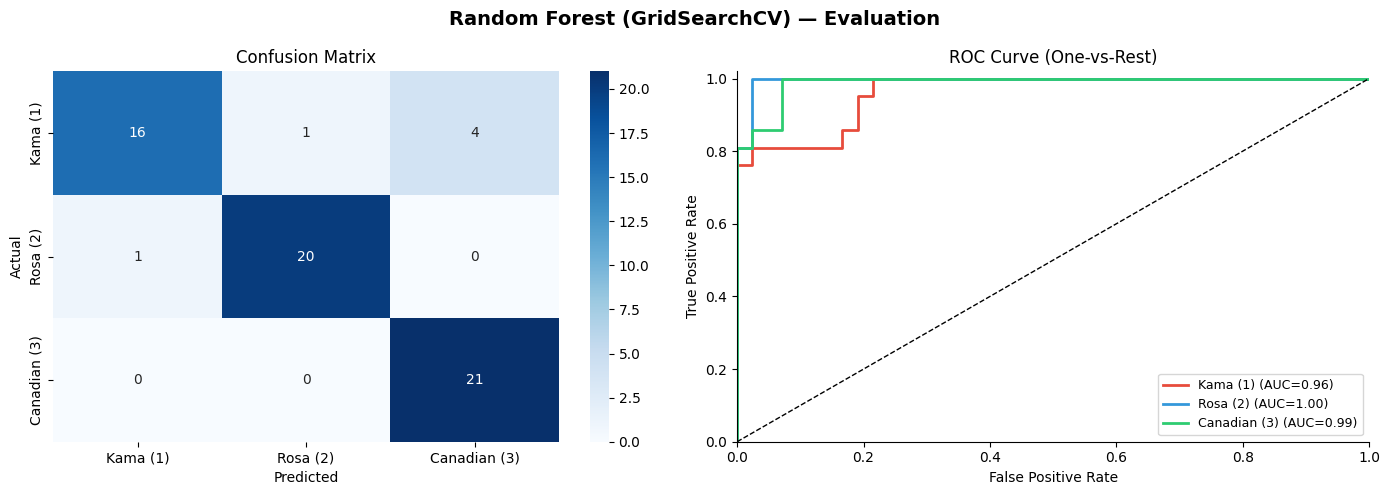

In [ ]:
print("  [Tuning 1/5] GridSearchCV — Random Forest\n")

# --- Không gian tìm kiếm ---
rf_param_grid = {
    'n_estimators'      : [50, 100, 200, 300],
    'max_depth'         : [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2']
}

rf_base   = RandomForestClassifier(random_state=RANDOM_SEED)
rf_grid   = GridSearchCV(
    estimator  = rf_base,
    param_grid = rf_param_grid,
    cv         = cv,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 1
)

t0 = time.time()
rf_grid.fit(X_train_sc, y_train)
t1 = time.time()

print(f"\n  Thời gian tìm kiếm : {t1-t0:.2f}s")
print(f"  Best params        : {rf_grid.best_params_}")
print(f"  Best CV F1-score   : {rf_grid.best_score_:.4f}\n")

# Đánh giá model tốt nhất
rf_best = rf_grid.best_estimator_
rf_results = evaluate_model(rf_best, X_test_sc, y_test,
                            model_name="Random Forest (GridSearchCV)",
                            class_names=CLASS_NAMES)

### RandomizedSearchCV: SVM

⚙️  [Tuning 2/5] RandomizedSearchCV — SVM

Fitting 5 folds for each of 50 candidates, totalling 250 fits

  Thời gian tìm kiếm : 5.80s
  Best params        : {'C': np.float64(9.551011649041131), 'degree': 4, 'gamma': np.float64(0.1561186404424365), 'kernel': 'rbf'}
  Best CV F1-score   : 0.9590

>> Kết quả trên tập Test (Holdout):
  📊 SVM (RandomizedSearchCV)
  Accuracy  : 0.8571
  Precision : 0.8555  (weighted)
  Recall    : 0.8571  (weighted)
  F1-score  : 0.8540  (weighted)
  AUC (OvR) : 0.9758

              precision    recall  f1-score   support

    Kama (1)       0.83      0.71      0.77        21
    Rosa (2)       0.86      0.90      0.88        21
Canadian (3)       0.87      0.95      0.91        21

    accuracy                           0.86        63
   macro avg       0.86      0.86      0.85        63
weighted avg       0.86      0.86      0.85        63



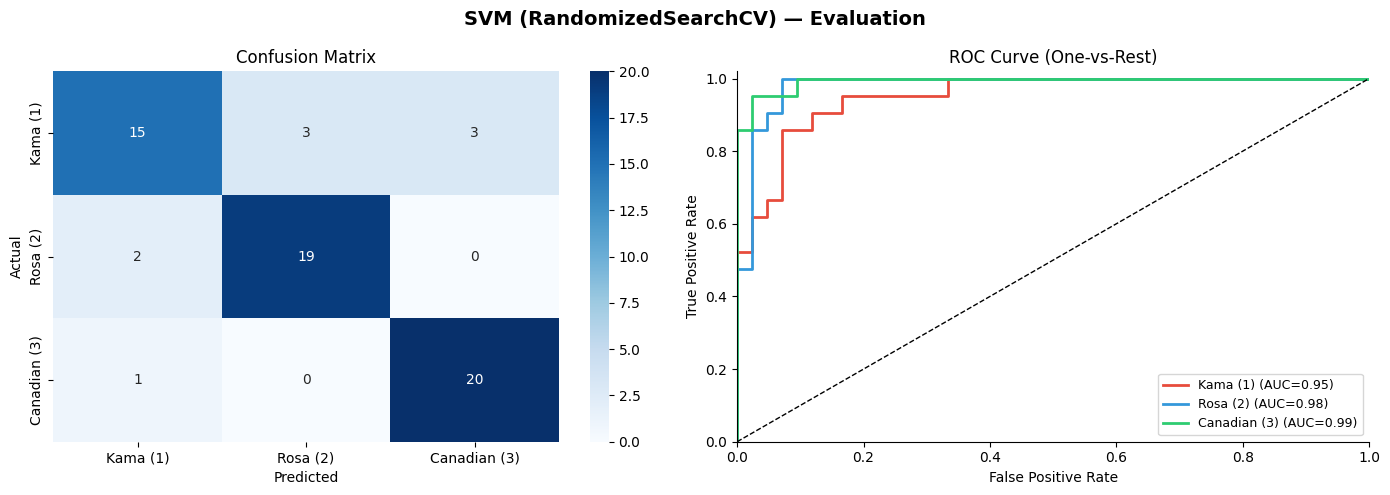

In [ ]:
print("  [Tuning 2/5] RandomizedSearchCV — SVM\n")    
from scipy.stats import uniform

# --- Không gian tìm kiếm (phân phối liên tục) ---
svm_param_dist = {
    'C'      : uniform(loc=0.01, scale=100),   # C nằm trong khoảng [0.01, 100.01]
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto'] + list(uniform(0.0001, 1).rvs(5)),
    'degree' : [2, 3, 4]                       # chỉ dùng khi kernel='poly'
}

svm_base   = SVC(probability=True, random_state=RANDOM_SEED)
svm_random = RandomizedSearchCV(
    estimator          = svm_base,
    param_distributions= svm_param_dist,
    n_iter             = 50,           # Máy sẽ bốc thử ngẫu nhiên 50 tổ hợp tham số
    cv                 = cv,
    scoring            = 'f1_weighted',
    random_state       = RANDOM_SEED,
    n_jobs             = -1,           # Chạy đa luồng cho nhanh
    verbose            = 1
)

import time
t0 = time.time()
svm_random.fit(X_train_sc, y_train)
t1 = time.time()

print(f"\n  Thời gian tìm kiếm : {t1-t0:.2f}s")
print(f"  Best params        : {svm_random.best_params_}")
print(f"  Best CV F1-score   : {svm_random.best_score_:.4f}\n")

# Đánh giá model tốt nhất
print(">> Kết quả trên tập Test (Holdout):")
svm_best = svm_random.best_estimator_
svm_results = evaluate_model(svm_best, X_test_sc, y_test,
                             model_name="SVM (RandomizedSearchCV)",
                             class_names=CLASS_NAMES)

### Tuning nâng cao: kNN + Gradient Boosting
> Dò siêu tham số cho 2 model thêm: kNN (n_neighbors, metric) và GBM (learning_rate, n_estimators, max_depth).

⚙️  [Tuning 3/5] GridSearchCV — kNN + Gradient Boosting

  [kNN] Thời gian chạy  : 10.38s
  [kNN] Best params     : {'metric': 'manhattan', 'n_neighbors': 4, 'p': 1, 'weights': 'uniform'}
  [kNN] Best CV F1      : 0.9529

  [GBM] Thời gian chạy  : 1226.02s
  [GBM] Best params     : {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.7}
  [GBM] Best CV F1      : 0.9457

>> Đánh giá kNN tốt nhất trên tập Test:
  📊 kNN (GridSearchCV)
  Accuracy  : 0.9048
  Precision : 0.9054  (weighted)
  Recall    : 0.9048  (weighted)
  F1-score  : 0.9047  (weighted)
  AUC (OvR) : 0.9843

              precision    recall  f1-score   support

    Kama (1)       0.86      0.86      0.86        21
    Rosa (2)       0.95      0.90      0.93        21
Canadian (3)       0.91      0.95      0.93        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90       

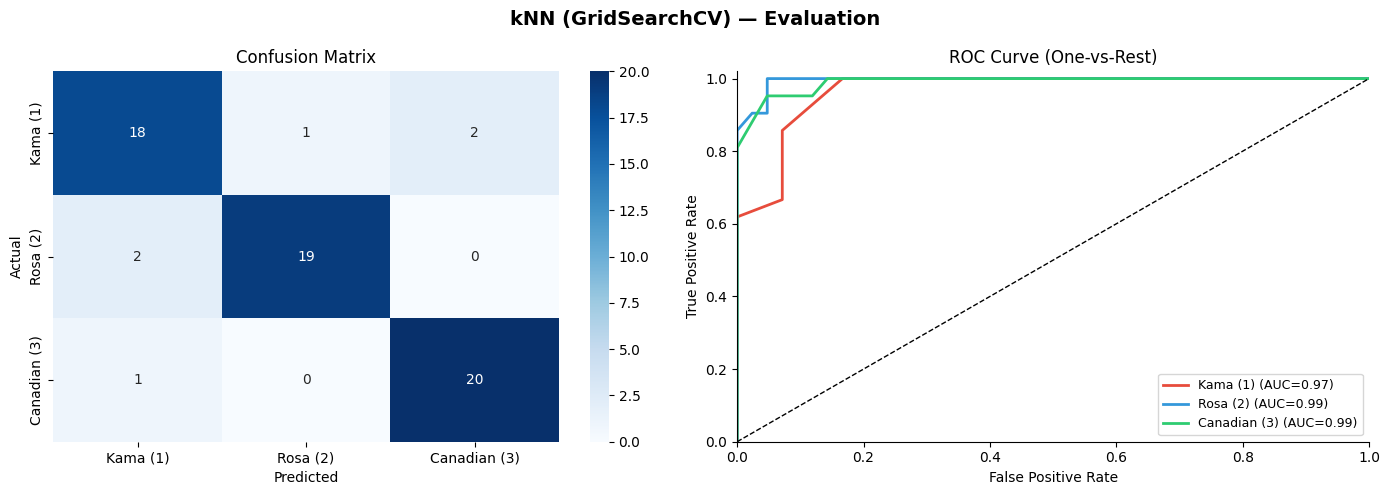


>> Đánh giá Gradient Boosting tốt nhất trên tập Test:
  📊 Gradient Boosting (GridSearchCV)
  Accuracy  : 0.9206
  Precision : 0.9239  (weighted)
  Recall    : 0.9206  (weighted)
  F1-score  : 0.9192  (weighted)
  AUC (OvR) : 0.9883

              precision    recall  f1-score   support

    Kama (1)       0.94      0.81      0.87        21
    Rosa (2)       0.95      0.95      0.95        21
Canadian (3)       0.88      1.00      0.93        21

    accuracy                           0.92        63
   macro avg       0.92      0.92      0.92        63
weighted avg       0.92      0.92      0.92        63



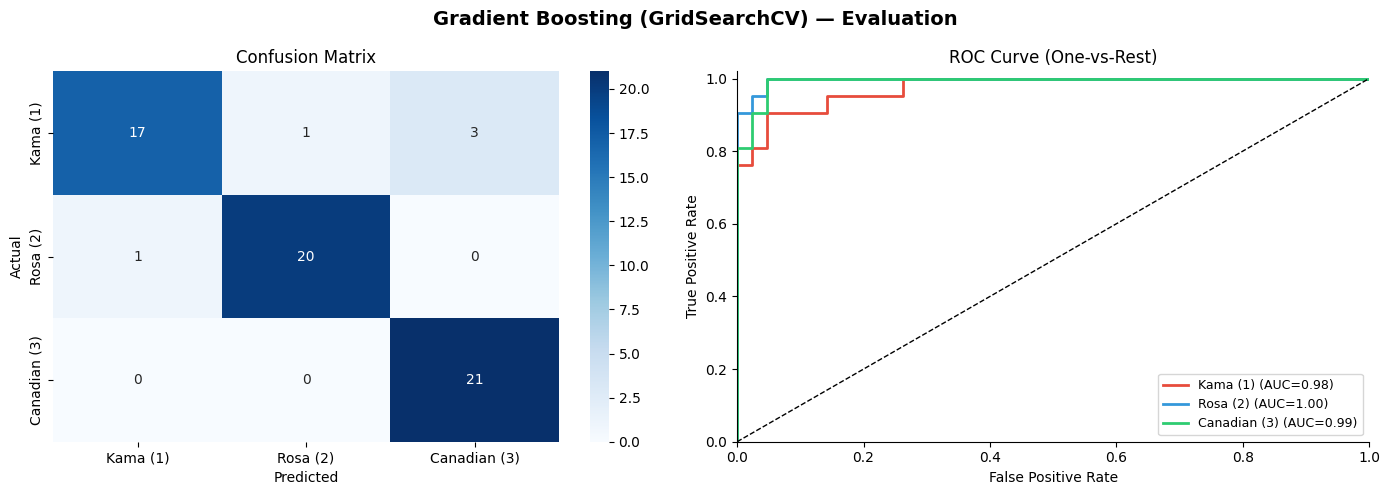

In [ ]:
import time
print("  [Tuning 3/5] GridSearchCV — kNN + Gradient Boosting\n")

# ==========================================
# 1. TUNING kNN (FULL GRID)
# ==========================================
knn_param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'minkowski'],
    'p'          : [1, 2]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid = knn_param_grid,
    cv         = cv,
    scoring    = 'f1_weighted',
    n_jobs     = -1
)

t0_knn = time.time()
knn_grid.fit(X_train_sc, y_train)
t1_knn = time.time()

knn_best = knn_grid.best_estimator_

print(f"  [kNN] Thời gian chạy  : {t1_knn - t0_knn:.2f}s")
print(f"  [kNN] Best params     : {knn_grid.best_params_}")
print(f"  [kNN] Best CV F1      : {knn_grid.best_score_:.4f}\n")

# ==========================================
# 2. TUNING GRADIENT BOOSTING (FULL GRID)
# ==========================================
gbm_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'max_depth'         : [3, 5, 7],
    'subsample'         : [0.7, 0.8, 1.0],
    'min_samples_split' : [2, 5]
}

gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    param_grid = gbm_param_grid,
    cv         = cv,
    scoring    = 'f1_weighted',
    n_jobs     = -1
)

t0_gbm = time.time()
gbm_grid.fit(X_train_sc, y_train)
t1_gbm = time.time()

gbm_best = gbm_grid.best_estimator_

print(f"  [GBM] Thời gian chạy  : {t1_gbm - t0_gbm:.2f}s")
print(f"  [GBM] Best params     : {gbm_grid.best_params_}")
print(f"  [GBM] Best CV F1      : {gbm_grid.best_score_:.4f}\n")

# ==========================================
# 3. ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print(">> Đánh giá kNN tốt nhất trên tập Test:")
knn_results = evaluate_model(knn_best, X_test_sc, y_test,
                             model_name="kNN (GridSearchCV)",
                             class_names=CLASS_NAMES)

print("\n>> Đánh giá Gradient Boosting tốt nhất trên tập Test:")
gbm_results = evaluate_model(gbm_best, X_test_sc, y_test,
                             model_name="Gradient Boosting (GridSearchCV)",
                             class_names=CLASS_NAMES)

### Ensemble: Stacking Classifier

⚙️  [Tuning 4/5] Ensemble — StackingClassifier

  Thời gian train stacking : 13.08s

>> Đánh giá Stacking Classifier trên tập Test:
  📊 Stacking Classifier
  Accuracy  : 0.8730
  Precision : 0.8721  (weighted)
  Recall    : 0.8730  (weighted)
  F1-score  : 0.8713  (weighted)
  AUC (OvR) : 0.9845

              precision    recall  f1-score   support

    Kama (1)       0.84      0.76      0.80        21
    Rosa (2)       0.90      0.90      0.90        21
Canadian (3)       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



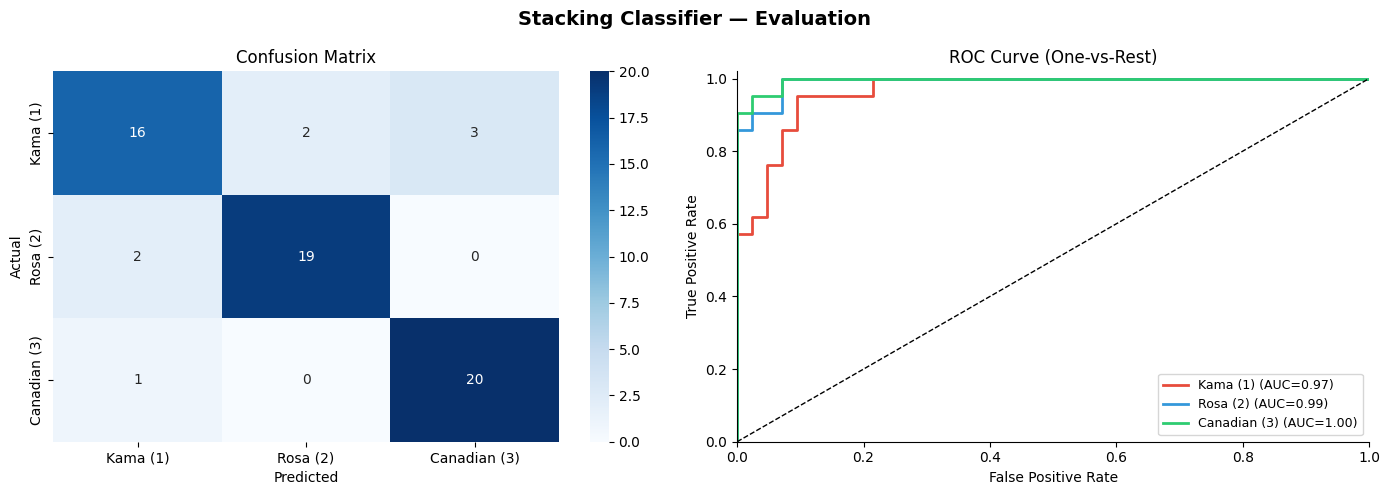

In [ ]:
print("  [Tuning 4/5] Ensemble — StackingClassifier\n")
import time
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

nb_m2 = GaussianNB()
mlp_m3 = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=RANDOM_SEED)

base_learners = [
    # --- 4 Models đã được bạn (Người 4) Tuning đỉnh cao ---
    ('rf_tuned' ,  rf_best),
    ('svm_tuned',  svm_best),
    ('knn_tuned',  knn_best),
    ('gbm_tuned',  gbm_best),

    # --- 2 Models đại diện bản sắc của Người 2 & 3 ---
    ('nb_baseline_M2', nb_m2),
    ('mlp_baseline_M3', mlp_m3)
]

# Meta-learner: Dùng Logistic Regression (đơn giản, chống Overfitting rất tốt)
meta_learner = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)

stacking_clf = StackingClassifier(
    estimators        = base_learners,
    final_estimator   = meta_learner,
    cv                = cv,
    stack_method      = 'predict_proba',
    passthrough       = False,   
    n_jobs            = -1
)

t0 = time.time()
stacking_clf.fit(X_train_sc, y_train)
t1 = time.time()

print(f"  Thời gian train stacking : {t1-t0:.2f}s\n")

print(">> Đánh giá Stacking Classifier trên tập Test:")
stacking_results = evaluate_model(stacking_clf, X_test_sc, y_test,
                                  model_name="Stacking Classifier",
                                  class_names=CLASS_NAMES)

### Ensemble: Soft Voting Classifier

⚙️  [Tuning 5/5] Ensemble — Soft Voting Classifier

  Thời gian train voting : 2.51s

>> Đánh giá Soft Voting Classifier trên tập Test:
  📊 Soft Voting Classifier
  Accuracy  : 0.9048
  Precision : 0.9066  (weighted)
  Recall    : 0.9048  (weighted)
  F1-score  : 0.9034  (weighted)
  AUC (OvR) : 0.9800

              precision    recall  f1-score   support

    Kama (1)       0.89      0.81      0.85        21
    Rosa (2)       0.95      0.90      0.93        21
Canadian (3)       0.88      1.00      0.93        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.90        63
weighted avg       0.91      0.90      0.90        63



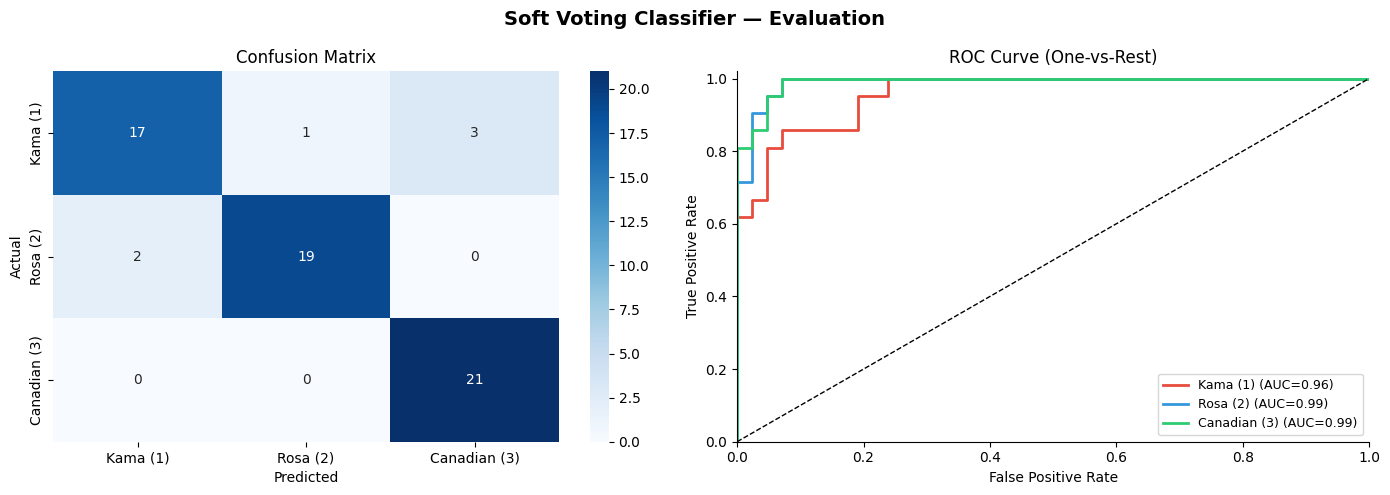

In [ ]:
print("  [Tuning 5/5] Ensemble — Soft Voting Classifier\n")
import time
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
nb_m2 = GaussianNB()
mlp_m3 = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=RANDOM_SEED)

voting_estimators = [
    ('rf_tuned' , rf_best),
    ('svm_tuned', svm_best),
    ('gbm_tuned', gbm_best),
    ('nb_baseline_M2', nb_m2),
    ('mlp_baseline_M3', mlp_m3)
]

voting_clf = VotingClassifier(
    estimators = voting_estimators,
    voting     = 'soft', 
    n_jobs     = -1
)

t0 = time.time()
voting_clf.fit(X_train_sc, y_train)
t1 = time.time()

print(f"  Thời gian train voting : {t1-t0:.2f}s\n")

print(">> Đánh giá Soft Voting Classifier trên tập Test:")
voting_results = evaluate_model(voting_clf, X_test_sc, y_test,
                                model_name="Soft Voting Classifier",
                                class_names=CLASS_NAMES)

### So sánh Tổng hợp: Trước & Sau Tuning

In [16]:
df_compare = pd.DataFrame(all_results).T[['accuracy', 'f1_weighted']].round(4)
df_compare.index.name = 'Model'

print("\n📋 Bảng so sánh Trước & Sau Tuning:\n")
# Chỉ gọi hiển thị cái bảng gốc, không dùng .style nữa
display(df_compare)


📋 Bảng so sánh Trước & Sau Tuning:



,accuracy,f1_weighted
Model,,
RF (baseline),0.9206,0.9192
SVM (baseline),0.8730,0.8713
kNN (baseline),0.8730,0.8713
GBM (baseline),0.9206,0.9198
RF (GridSearch),0.9048,0.9025
SVM (RandomSearch),0.8571,0.8540
kNN (GridSearch),0.9048,0.9047
GBM (GridSearch),0.9206,0.9192
Stacking,0.8730,0.8713


### Lưu Kết quả Best Model

In [17]:
import joblib

# Tìm model tốt nhất theo Accuracy
tuned_models = {
    'RF (GridSearch)'  : (rf_best,       rf_results),
    'SVM (RandomSearch)': (svm_best,     svm_results),
    'kNN (GridSearch)' : (knn_best,      knn_results),
    'GBM (GridSearch)' : (gbm_best,      gbm_results),
    'Stacking'         : (stacking_clf,  stacking_results),
    'Soft Voting'      : (voting_clf,    voting_results),
}

best_name = max(tuned_models, key=lambda k: tuned_models[k][1]['accuracy'])
best_model_obj = tuned_models[best_name][0]

print(f"   Best model: {best_name}")
print(f"   Accuracy : {tuned_models[best_name][1]['accuracy']:.4f}")
print(f"   F1-score : {tuned_models[best_name][1]['f1']:.4f}\n")

# Lưu model
joblib.dump(best_model_obj, 'wheat_seeds_best_model.pkl')
joblib.dump(scaler,          'wheat_seeds_scaler.pkl')
print("✅ Đã lưu: wheat_seeds_best_model.pkl & wheat_seeds_scaler.pkl")

   Best model: GBM (GridSearch)
   Accuracy : 0.9206
   F1-score : 0.9192

✅ Đã lưu: wheat_seeds_best_model.pkl & wheat_seeds_scaler.pkl
